
--- Задание №2: Теоретический расчет ---
+-----------+----------+------+------------+
| Вариант   |   lambda |   mu |   L (теор) |
+===========+==========+======+============+
| Вариант 1 |      0.5 |  0.4 |     0.9485 |
+-----------+----------+------+------------+
| Вариант 2 |      1   |  0.4 |     1.4778 |
+-----------+----------+------+------------+
| Вариант 3 |      4   |  0.4 |     1.8902 |
+-----------+----------+------+------------+

--- Задание №3: Поиск предельного числа заявок (условие: при симуляциях колеблется в пределах 10%) ---
+-----------+---------------+------------+--------------------------+
| Вариант   |   N (найдено) |   L (теор) |   L (сред. имитационное) |
+===========+===============+============+==========================+
| Вариант 1 |           850 |     0.9485 |                   0.9488 |
+-----------+---------------+------------+--------------------------+
| Вариант 2 |           350 |     1.4778 |                   1.4607 |
+-----------+---------------+

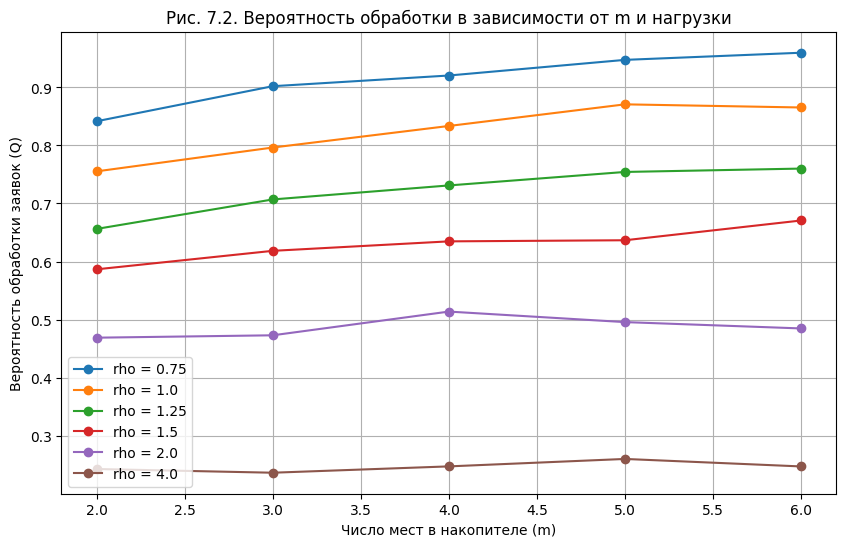

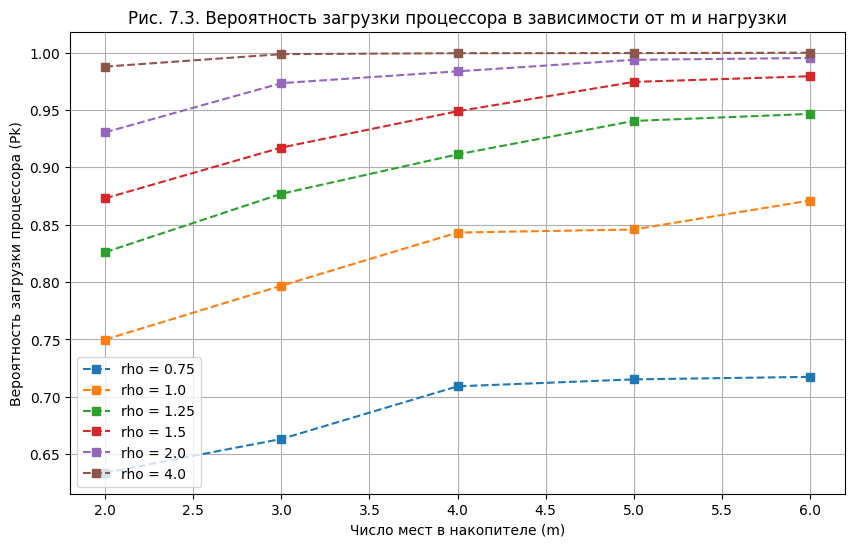

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tabulate import tabulate

# --- Блок моделирования (Задание №1) ---

class SingleChannelSystem:
    """
    Класс для имитационного моделирования одноканальной СМО с накопителем.
    """
    def __init__(self, m, lam, mu):
        self.m = m  # количество мест в накопителе
        self.lam = lam  # интенсивность входящего потока
        self.mu = mu  # интенсивность обслуживания
        self.reset()

    def reset(self):
        self.time = 0
        self.in_service = False
        self.queue = 0
        self.arrival_count = 0
        self.served_count = 0
        self.rejected_count = 0

        # Переменные для сбора статистики
        self.last_event_time = 0
        self.queue_time_integral = 0  # интеграл длины очереди по времени
        self.busy_time = 0  # суммарное время занятости канала

    def simulate(self, num_arrivals):
        """
        Запуск имитации до достижения заданного количества заявок.
        """
        self.reset()
        # Время до следующего прихода (экспоненциальное распределение)
        next_arrival = random.expovariate(self.lam)
        # Время до окончания обслуживания (бесконечность, если канал пуст)
        next_departure = float('inf')

        while self.arrival_count < num_arrivals:
            # Определяем время ближайшего события
            event_time = min(next_arrival, next_departure)
            delta = event_time - self.last_event_time

            # Обновляем статистики перед переходом к новому состоянию
            self.queue_time_integral += self.queue * delta
            if self.in_service:
                self.busy_time += delta

            self.time = event_time
            self.last_event_time = event_time

            if next_arrival <= next_departure:
                # Событие: Приход заявки
                self.arrival_count += 1
                if not self.in_service:
                    self.in_service = True
                    next_departure = self.time + random.expovariate(self.mu)
                elif self.queue < self.m:
                    self.queue += 1
                else:
                    self.rejected_count += 1
                next_arrival = self.time + random.expovariate(self.lam)
            else:
                # Событие: Завершение обслуживания
                self.served_count += 1
                if self.queue > 0:
                    self.queue -= 1
                    next_departure = self.time + random.expovariate(self.mu)
                else:
                    self.in_service = False
                    next_departure = float('inf')

        # Вычисление выходных характеристик
        stats = {
            "L": self.queue_time_integral / self.time,  # среднее число заявок в накопителе
            "Q": self.served_count / self.arrival_count,  # относительная пропускная способность
            "Pk": self.busy_time / self.time  # вероятность загрузки процессора
        }
        return stats

# --- Теоретический расчет (Задание №2) ---

def theoretical_calculation(m, lam, mu):
    rho = lam / mu
    # Расчет вероятности состояния P0 (система пуста)
    if rho == 1.0:
        p0 = 1 / (m + 2)
    else:
        p0 = (1 - rho) / (1 - rho**(m + 2))

    # Среднее число заявок в очереди L
    L = 0
    for i in range(1, m + 1):
        # Вероятность состояния с i заявками в очереди: P(i+1) = rho^(i+1) * P0
        p_queue_i = (rho**(i + 1)) * p0
        L += i * p_queue_i

    # Вероятность отказа (все места заняты)
    pf = (rho**(m + 1)) * p0
    Q = 1 - pf
    Pk = 1 - p0

    return {"L": L, "Q": Q, "Pk": Pk}

# --- Функции для вывода результатов и графиков ---

def run_task_2():
    print("\n--- Задание №2: Теоретический расчет ---")
    variants = [
        {"name": "Вариант 1", "m": 2, "lam": 0.5, "mu": 0.4},
        {"name": "Вариант 2", "m": 2, "lam": 1.0, "mu": 0.4},
        {"name": "Вариант 3", "m": 2, "lam": 4.0, "mu": 0.4},
    ]
    results = []
    for var in variants:
        res = theoretical_calculation(var['m'], var['lam'], var['mu'])
        results.append([var['name'], var['lam'], var['mu'], round(res['L'], 4)])

    print(tabulate(results, headers=["Вариант", "lambda", "mu", "L (теор)"], tablefmt="grid"))

def run_task_3():
    print("\n--- Задание №3: Поиск предельного числа заявок (условие: при симуляциях колеблется в пределах 10%) ---")
    variants = [
        {"name": "Вариант 1", "m": 2, "lam": 0.5, "mu": 0.4},
        {"name": "Вариант 2", "m": 2, "lam": 1.0, "mu": 0.4},
        {"name": "Вариант 3", "m": 2, "lam": 4.0, "mu": 0.4},
    ]

    final_table = []
    num_simulations = 20  # Количество проверочных симуляций для каждого N

    for var in variants:
        theory_res = theoretical_calculation(var['m'], var['lam'], var['mu'])
        theory_L = theory_res['L']
        model = SingleChannelSystem(var['m'], var['lam'], var['mu'])

        found_n = "Не найдено до 10к"
        final_L_avg = 0

        # Цикл по количеству заявок N.
        # Начнем со 100 и будем увеличивать с шагом 50 для скорости, до 10 000.
        for n_arrivals in range(100, 10001, 50):
            all_within_limit = True
            temp_L_sum = 0

            for _ in range(num_simulations):
                sim_res = model.simulate(n_arrivals)
                l_sim = sim_res['L']
                temp_L_sum += l_sim

                # Проверка отклонения (избегаем деления на 0, если L_теор вдруг 0)
                deviation = abs(l_sim - theory_L) / theory_L if theory_L != 0 else l_sim

                if deviation > 0.10:
                    all_within_limit = False
                    break # Прерываем серию из 20, если хоть одна симуляция не прошла

            if all_within_limit:
                found_n = n_arrivals
                final_L_avg = temp_L_sum / num_simulations
                break

        final_table.append([var['name'], found_n, round(theory_L, 4), round(final_L_avg, 4)])

    print(tabulate(final_table, headers=["Вариант", "N (найдено)", "L (теор)", "L (сред. имитационное)"], tablefmt="grid"))
    print("Вывод: Чем выше нагрузка системы (rho), тем быстрее имитационная модель стабилизируется.")

def plot_processing_probability(data_results, rho_values, m_range):
    plt.figure(figsize=(10, 6))
    for rho in rho_values:
        y_values = [data_results[rho][m]['Q'] for m in m_range]
        plt.plot(m_range, y_values, marker='o', label=f'rho = {rho}')

    plt.title("Рис. 7.2. Вероятность обработки в зависимости от m и нагрузки")
    plt.xlabel("Число мест в накопителе (m)")
    plt.ylabel("Вероятность обработки заявок (Q)")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_processor_load(data_results, rho_values, m_range):
    plt.figure(figsize=(10, 6))
    for rho in rho_values:
        y_values = [data_results[rho][m]['Pk'] for m in m_range]
        plt.plot(m_range, y_values, marker='s', linestyle='--', label=f'rho = {rho}')

    plt.title("Рис. 7.3. Вероятность загрузки процессора в зависимости от m и нагрузки")
    plt.xlabel("Число мест в накопителе (m)")
    plt.ylabel("Вероятность загрузки процессора (Pk)")
    plt.grid(True)
    plt.legend()
    plt.show()

def run_task_4():
    print("\n--- Задание №4: Исследование зависимостей (подготовка данных для графиков) ---")
    rho_values = [0.75, 1.0, 1.25, 1.5, 2.0, 4.0]
    m_range = range(2, 7) # m от 2 до 6
    mu = 1.0 # фиксируем mu для простоты, меняем lambda для изменения rho

    results = {rho: {} for rho in rho_values}

    for rho in rho_values:
        lam = rho * mu
        for m in m_range:
            model = SingleChannelSystem(m, lam, mu)
            # Берем достаточно большое число заявок для плавности графиков
            res = model.simulate(10000)
            results[rho][m] = res

    print("Данные собраны. Визуализация графиков...")
    plot_processing_probability(results, rho_values, m_range)
    plot_processor_load(results, rho_values, m_range)

# --- Основной цикл выполнения ---

if __name__ == "__main__":
    # Выполнение по порядку
    run_task_2()
    run_task_3()
    run_task_4()
